
#### Análisis y Procesamiento de Señales


# Trabajo Práctico Nº2
#### Angel Joseph Vargas Martinez


# Introducción

En esta tarea se continúa con la simulación del proceso de digitalización de señales mediante un conversor analógico-digital (ADC). En la etapa previa se modeló únicamente el bloque de cuantización; en esta instancia se incorpora además el proceso de muestreo, completando así un modelo más realista del sistema.

El objetivo principal es analizar el comportamiento de un ADC de $B$ bits al digitalizar una señal senoidal contaminada con ruido aditivo. La señal de entrada se define como:

$$
s_R = s + n
$$

donde $s$ es una senoidal de frecuencia $f_0$ y energía normalizada, y $n$ es una secuencia de ruido gaussiano blanco, incorrelado con la señal.

El nivel de ruido se controla mediante un factor $k_n$, que escala la potencia del ruido de cuantización:

$$
P_n = k_n \cdot P_q
$$

con:

$$
P_q = \frac{q^2}{12}
$$

siendo $q$ el paso de cuantización:

$$
q = \frac{2 V_F}{2^B}
$$

Se establecen los parámetros del conversor siendo : $B$ el Número de bits y $\pm V_F$ el Rango dinámico:
Este parámetro $q$ determina la resolución del ADC.



## Ruido
Para la generacion de ruido $n$, se genera una secuencia de ruido gaussiano con media nula y varianza:

$$
\sigma^2 = k_n \cdot \frac{q^2}{12}
$$

Este ruido es incorrelado y se suma a la señal original:

$$
s_R[n] = s[n] + n[n]
$$


## Cuantización

El proceso de cuantización se modela como:

$$
s_Q[n] = \text{round}\left(\frac{s_R[n]}{q}\right)\cdot q
$$

El error de cuantización queda definido como:

$$
e[n] = s_Q[n] - s_R[n]
$$


## Análisis espectral (FFT)

La Transformada Rápida de Fourier (FFT, *Fast Fourier Transform*) es un algoritmo eficiente que permite calcular la Transformada Discreta de Fourier (DFT) de una señal.

La DFT transforma una señal del dominio del tiempo al dominio de la frecuencia, permitiendo identificar las componentes espectrales presentes en la señal. Matemáticamente, se define como:

$$
X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j 2\pi kn/N}
$$

donde:

 $x[n]$ es la señal en el tiempo
 
 $X[k]$ representa su contenido en frecuencia
 
 $N$ es la cantidad de muestras

La FFT reduce el costo computacional de esta operación de $O(N^2)$ a $O(N \log N)$

La potencia espectral se calcula como:

$$
P_{xx} = \frac{|X[k]|^2}{N^2}
$$

Luego se obtiene el espectro unilateral, considerando únicamente las frecuencias positivas, y se expresa en escala logarítmica (dB):

$$
P_{dB} = 10 \log_{10}(P_{xx})
$$



In [35]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(0, nn) / fs
    velang = 2 * np.pi * ff
    xx = dc + vmax * np.sin(velang * tt + ph)
    return tt, xx

Aca se ingresan los valores de la consigna a) y se generan tres señales

La senoidal "pura" sin ruido

La senoidal con ruido

La senoidal cuantizada

In [36]:
# ==================================================
# Valores de la senoidal
# ==================================================
N = 1000
fs = N
df = fs / N
ffs = df     # tono en fs/4 = 250 Hz
dcs = 0
fas = 0
vnor = np.sqrt(2)

# ==================================================
# Valores del ADC y ruido
# ==================================================
B = 4
Vfs = 2
qq = 2 * Vfs / 2**B

k = 1
sigma = k * (qq**2) / 12
mu = 0

# ruido gaussiano incorrelado
U_n = np.random.normal(mu, np.sqrt(sigma), N)

# ==================================================
# Señales
# ==================================================
tt, xx = mi_funcion_sen(vmax=vnor, dc=dcs, ff=ffs, ph=fas, nn=N, fs=fs)

xxun = xx + U_n
xxq = np.round(xxun / qq) * qq


  


Aca se grafican las tres señales, donde se observa que es una senoidal de $1Hz$, que la primera señal es la senoidal "pura" (la más limpia), la señal con ruido y la señal despues del ADC, en donde se observan partes cuadraticas debido a los redondeos

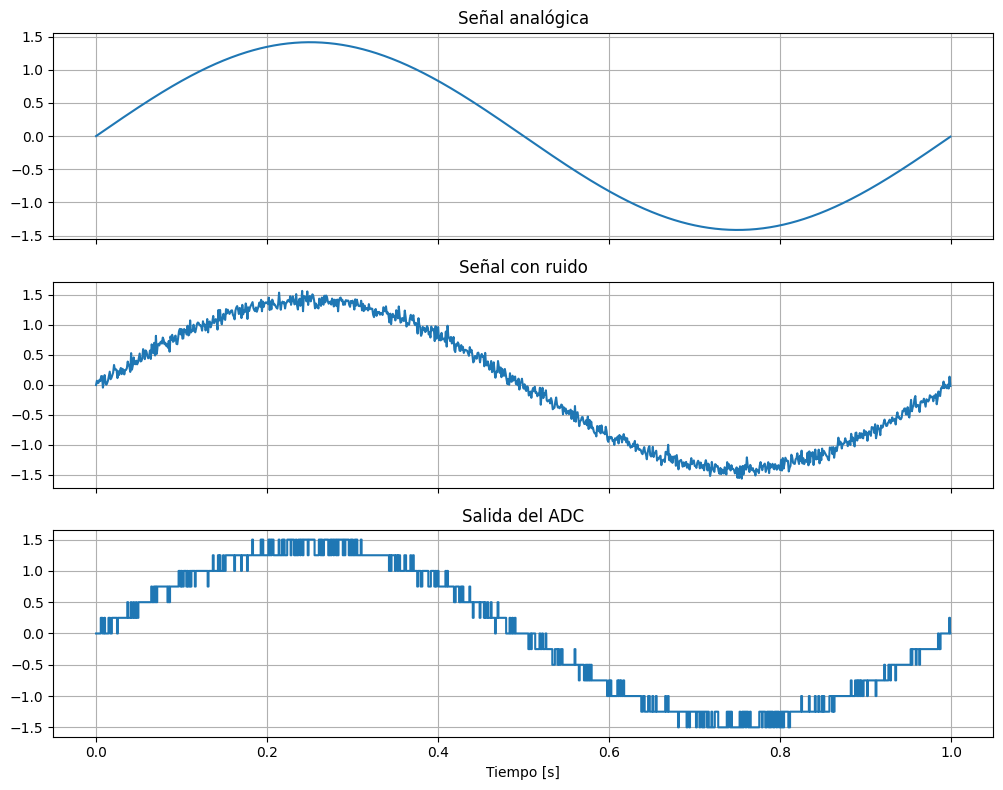

In [37]:
# ==================================================
# Señales temporales
# ==================================================
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(tt, xx)
ax[0].set_title('Señal analógica')
ax[0].grid(True)

ax[1].plot(tt, xxun)
ax[1].set_title('Señal con ruido')
ax[1].grid(True)

ax[2].step(tt, xxq, where='mid')
ax[2].set_title('Salida del ADC')
ax[2].set_xlabel('Tiempo [s]')
ax[2].grid(True)

plt.tight_layout()
plt.show()


Se calculo la FFT de las 3 señales, y a su vez la potencia de las mismas siendo normalizadas y agarrando la parte positiva de la frecuencia, y por ultimo se paso a dB


In [38]:

# ==================================================
# FFT
# ==================================================
frec = np.arange(N) * df

XX = np.fft.fft(xx)
XXun = np.fft.fft(xxun)
XXq = np.fft.fft(xxq)

# ==================================================
# Potencia bilateral y normalizada
# ==================================================
Pxx = (np.abs(XX)**2) / (N**2)
Pxxun = (np.abs(XXun)**2) / (N**2)
Pxxq = (np.abs(XXq)**2) / (N**2)

# ==================================================
# Espectro unilateral
# ==================================================
frec_half = frec[:N//2 + 1]

Pxx_uni = Pxx[:N//2 + 1].copy()
Pxxun_uni = Pxxun[:N//2 + 1].copy()
Pxxq_uni = Pxxq[:N//2 + 1].copy()

Pxx_uni[1:-1] *= 2
Pxxun_uni[1:-1] *= 2
Pxxq_uni[1:-1] *= 2

# ==================================================
# Conversión a dB
# ==================================================
Pxx_uni_db = 10 * np.log10(Pxx_uni + 1e-12)
Pxxun_uni_db = 10 * np.log10(Pxxun_uni + 1e-12)
Pxxq_uni_db = 10 * np.log10(Pxxq_uni + 1e-12)





## Piso de ruido

El piso de ruido representa el nivel de potencia promedio del ruido en el dominio frecuencial. En el espectro, se observa como una “base” sobre la cual se destaca la señal. Se calcularon dos tipos de ruidos el "teorico" y el "practico", los cuales deberian dar valores cercanos entre si

### Piso de ruido teórico

El piso de ruido teórico se obtiene a partir de la varianza del ruido $\sigma^2$ y la cantidad de muestras $N$:

$$
P_{teo} = 10 \log_{10}\left(\frac{2\sigma^2}{N}\right)
$$

Este resultado surge de considerar que el ruido blanco distribuye su energía de manera uniforme en todas las frecuencias. Al calcular la FFT, la potencia total del ruido se reparte entre los distintos bins del espectro. El factor 2 aparece debido a que se trabaja con espectro unilateral, concentrando la energía de frecuencias negativas en las positivas.

### Piso de ruido práctico

El piso de ruido práctico se obtiene directamente a partir de la simulación. Para ello, se calcula el promedio de la potencia espectral en los bins donde no se encuentra la señal:

$$
P_{pract} = 10 \log_{10}(\text{media de los bins de ruido})
$$

Este valor representa el nivel real de ruido observado en el espectro.


In [39]:
# ==================================================
# Pisos teóricos (solo para referencia)
# ==================================================
piso_analogico_teo = 10 * np.log10(2 * sigma / N)
sigma_q = qq**2 / 12
piso_digital_teo = 10 * np.log10(2 * sigma_q / N)



# ==================================================
# Pisos prácticos
# ==================================================
bin_tono = int(ffs / df)

ruido_analogico_lin = np.delete(Pxxun_uni, [0, bin_tono])
ruido_digital_lin = np.delete(Pxxq_uni, [0, bin_tono])

piso_analogico_practico = 10 * np.log10(np.mean(ruido_analogico_lin))
piso_digital_practico = 10 * np.log10(np.mean(ruido_digital_lin))

print(f"Piso analógico teórico  = {piso_analogico_teo:.2f} dB")
print(f"Piso analógico práctico = {piso_analogico_practico:.2f} dB")
print()
print(f"Piso digital teórico    = {piso_digital_teo:.2f} dB")
print(f"Piso digital práctico   = {piso_digital_practico:.2f} dB")


Piso analógico teórico  = -49.82 dB
Piso analógico práctico = -50.15 dB

Piso digital teórico    = -49.82 dB
Piso digital práctico   = -46.65 dB


Hay dos tipos de piso de ruido el analogico y el digital, el primero es el ruido gaussiano que se le mete a la señal "pura" antes de pasar por el conversor ADC, y el segundo es el ruido que se le agrega al pasar por el conversor ADC.

Se observa que los valores calculados tanto teoricos como practicos no son muy distintos y que los teoricos coinciden entre si porque la potencia de ruido es la misma

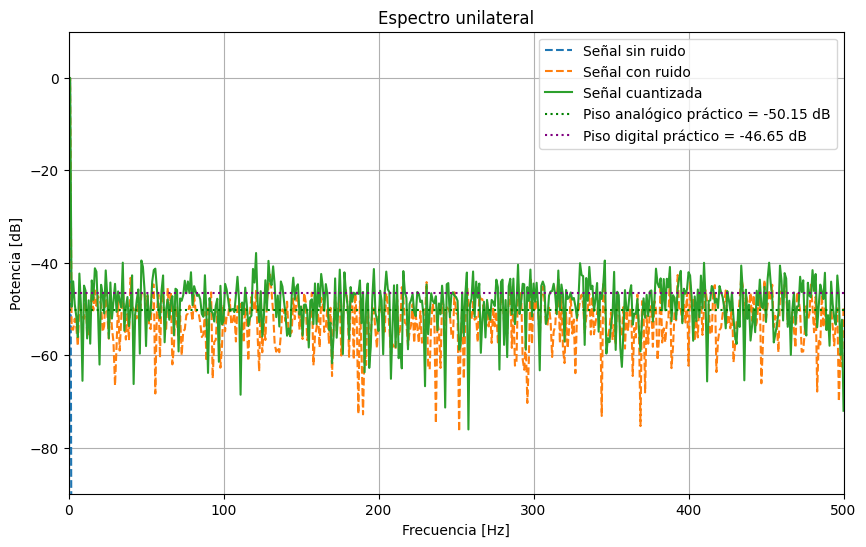

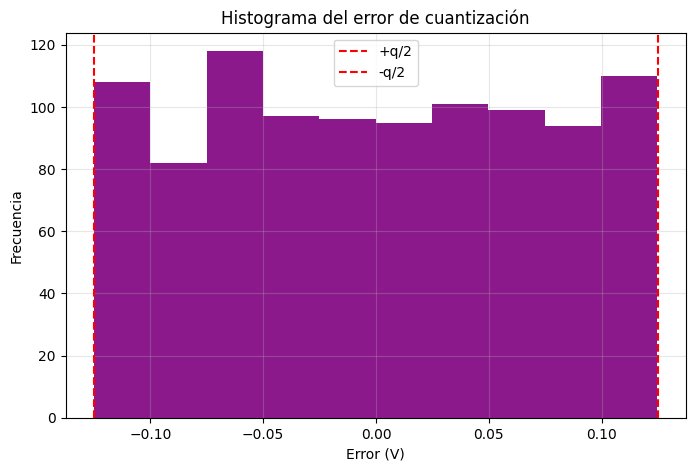

In [42]:

# ==================================================
# Gráfico espectral
# ==================================================
plt.figure(figsize=(10, 6))

plt.plot(frec_half, Pxx_uni_db, '--', label='Señal sin ruido')
plt.plot(frec_half, Pxxun_uni_db, '--', label='Señal con ruido')
plt.plot(frec_half, Pxxq_uni_db, label='Señal cuantizada')

# SOLO pisos prácticos
plt.axhline(piso_analogico_practico, color='green', linestyle=':',
            label=f'Piso analógico práctico = {piso_analogico_practico:.2f} dB')

plt.axhline(piso_digital_practico, color='purple', linestyle=':',
            label=f'Piso digital práctico = {piso_digital_practico:.2f} dB')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.title('Espectro unilateral')
plt.ylim(-90, 10)
plt.xlim(0, fs/2)
plt.grid(True)
plt.legend()
plt.show()

# ==================================================
# Error de cuantización
# ==================================================
xxe = xxq - xxun

plt.figure(figsize=(8, 5))
plt.hist(xxe, bins=10, density=False, alpha=0.9, color='purple')
plt.axvline(qq/2, color='red', linestyle='--', label='+q/2')
plt.axvline(-qq/2, color='red', linestyle='--', label='-q/2')
plt.title('Histograma del error de cuantización')
plt.xlabel('Error (V)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

En primer lugar, al analizar la señal senoidal sin ruido en el dominio frecuencial, se observa que su espectro está compuesto por un único pico bien definido, debido a que la Transformada de Fourier de una senoidal ideal, onsiste en una delta de Dirac centrada en la frecuencia de la señal. En el caso discreto, esta propiedad se traduce en que toda la energía de la señal se concentra en un único bin de la FFT, siempre que la frecuencia de la senoidal coincida exactamente con un múltiplo de la resolución espectral $\Delta f$. 

Cuando se introduce ruido gaussiano aditivo, el espectro se modifica de manera significativa. El pico correspondiente a la senoidal se mantiene pero  aparece un nivel de fondo aproximadamente constante a lo largo de todas las frecuencias. Este nivel corresponde al ruido blanco, cuya principal característica es distribuir su energía de forma uniforme en el dominio frecuencial. Este fenómeno da lugar al denominado piso de ruido analógico, que representa la potencia promedio del ruido en cada bin del espectro.

Al aplicar el proceso de cuantización, la señal digitalizada presenta un comportamiento similar, pero con un incremento adicional en el piso de ruido, una introducción del ruido de cuantización. Como resultado, el piso de ruido observado en la señal cuantizada es la combinación del ruido analógico previamente presente y del ruido introducido por el ADC.


Finalmente, se analiza el error de cuantización definido como:

$$
e[n] = s_Q[n] - s_R[n]
$$

El histograma de este error permite estudiar su comportamiento estadístico. En los resultados obtenidos se observa que el error se encuentra acotado dentro del intervalo $[-q/2, \, q/2]$, lo cual es consistente con el modelo teórico de cuantización uniforme.

Además, la distribución del error tiende a ser aproximadamente uniforme dentro de dicho intervalo. Esto se debe a que, cuando la señal de entrada utiliza de manera adecuada los niveles del cuantizador y no presenta correlación con el error, el proceso de cuantización puede modelarse como una fuente de ruido blanco uniforme. El hecho de que el histograma sea aproximadamente plano indica que todos los valores del error dentro del rango permitido son igualmente probables, lo cual refuerza la hipótesis de que el ruido de cuantización puede tratarse como una señal aleatoria independiente.


### Introduccion de los valores del punto b) 
$k= 1/10 $, $B=4$  y graficos de las señales 

Piso analógico teórico  = -59.82 dB
Piso analógico práctico = -59.44 dB

Piso digital teórico    = -49.82 dB
Piso digital práctico   = -48.74 dB


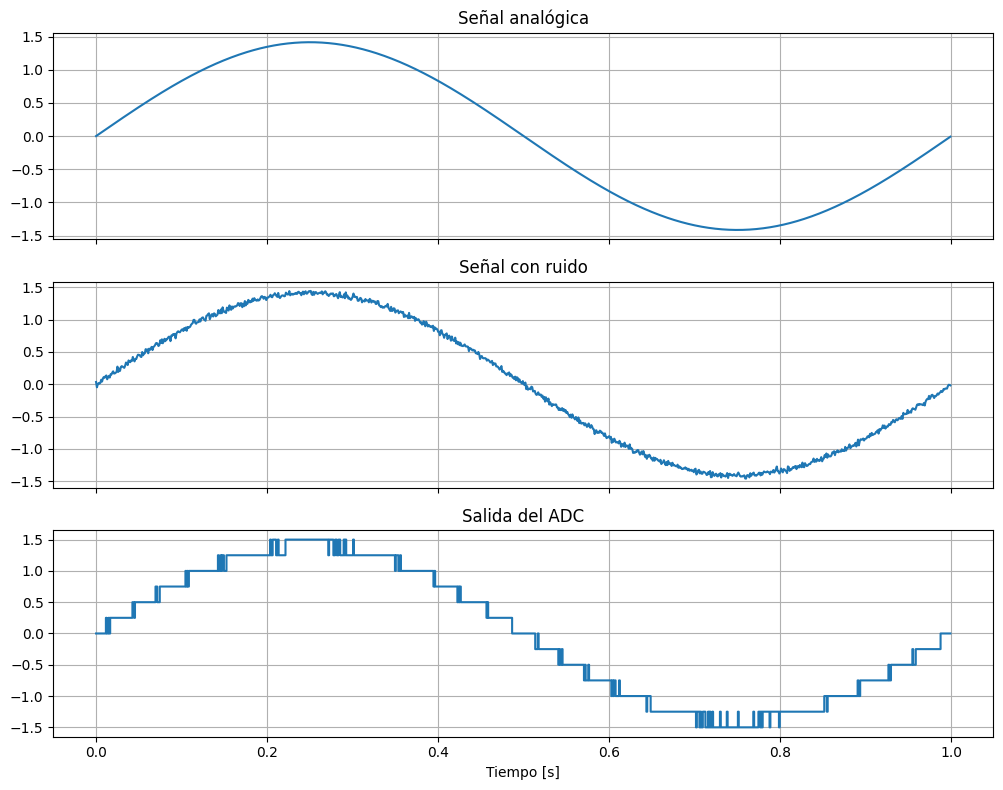

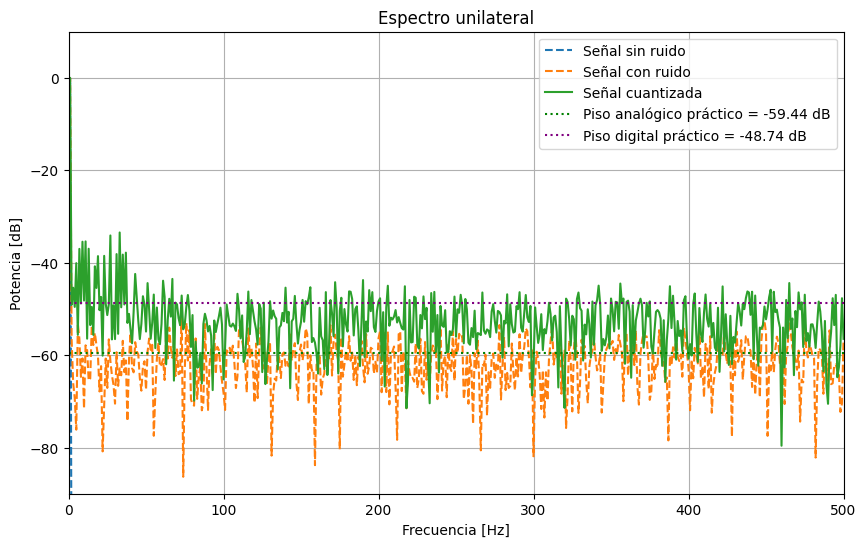

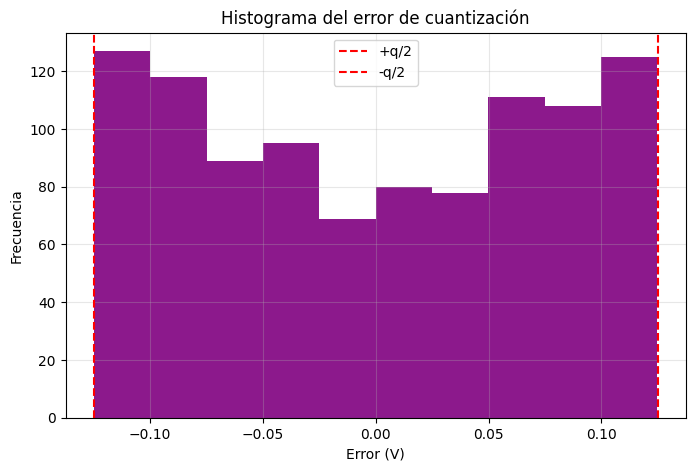

In [22]:

B=4
k=1/10
qq=2*Vfs/2**B
sigma =k* (qq**2)/12

# ruido gaussiano incorrelado
U_n = np.random.normal(mu, np.sqrt(sigma), N)

# ==================================================
# Señales
# ==================================================
tt, xx = mi_funcion_sen(vmax=vnor, dc=dcs, ff=ffs, ph=fas, nn=N, fs=fs)

xxun = xx + U_n
xxq = np.round(xxun / qq) * qq

# ==================================================
# FFT
# ==================================================
frec = np.arange(N) * df

XX = np.fft.fft(xx)
XXun = np.fft.fft(xxun)
XXq = np.fft.fft(xxq)

# ==================================================
# Potencia bilateral y normalizada
# ==================================================
Pxx = (np.abs(XX)**2) / (N**2)
Pxxun = (np.abs(XXun)**2) / (N**2)
Pxxq = (np.abs(XXq)**2) / (N**2)

# ==================================================
# Espectro unilateral
# ==================================================
frec_half = frec[:N//2 + 1]

Pxx_uni = Pxx[:N//2 + 1].copy()
Pxxun_uni = Pxxun[:N//2 + 1].copy()
Pxxq_uni = Pxxq[:N//2 + 1].copy()

Pxx_uni[1:-1] *= 2
Pxxun_uni[1:-1] *= 2
Pxxq_uni[1:-1] *= 2

# ==================================================
# Conversión a dB
# ==================================================
Pxx_uni_db = 10 * np.log10(Pxx_uni + 1e-12)
Pxxun_uni_db = 10 * np.log10(Pxxun_uni + 1e-12)
Pxxq_uni_db = 10 * np.log10(Pxxq_uni + 1e-12)

# ==================================================
# Pisos teóricos (solo para referencia)
# ==================================================
piso_analogico_teo = 10 * np.log10(2 * sigma / N)
sigma_q = qq**2 / 12
piso_digital_teo = 10 * np.log10(2 * sigma_q / N)

# ==================================================
# Pisos prácticos
# ==================================================
bin_tono = int(ffs / df)

ruido_analogico_lin = np.delete(Pxxun_uni, [0, bin_tono])
ruido_digital_lin = np.delete(Pxxq_uni, [0, bin_tono])

piso_analogico_practico = 10 * np.log10(np.mean(ruido_analogico_lin))
piso_digital_practico = 10 * np.log10(np.mean(ruido_digital_lin))

print(f"Piso analógico teórico  = {piso_analogico_teo:.2f} dB")
print(f"Piso analógico práctico = {piso_analogico_practico:.2f} dB")
print()
print(f"Piso digital teórico    = {piso_digital_teo:.2f} dB")
print(f"Piso digital práctico   = {piso_digital_practico:.2f} dB")

# ==================================================
# Señales temporales
# ==================================================
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(tt, xx)
ax[0].set_title('Señal analógica')
ax[0].grid(True)

ax[1].plot(tt, xxun)
ax[1].set_title('Señal con ruido')
ax[1].grid(True)

ax[2].step(tt, xxq, where='mid')
ax[2].set_title('Salida del ADC')
ax[2].set_xlabel('Tiempo [s]')
ax[2].grid(True)

plt.tight_layout()
plt.show()

# ==================================================
# Gráfico espectral
# ==================================================
plt.figure(figsize=(10, 6))

plt.plot(frec_half, Pxx_uni_db, '--', label='Señal sin ruido')
plt.plot(frec_half, Pxxun_uni_db, '--', label='Señal con ruido')
plt.plot(frec_half, Pxxq_uni_db, label='Señal cuantizada')

# SOLO pisos prácticos
plt.axhline(piso_analogico_practico, color='green', linestyle=':',
            label=f'Piso analógico práctico = {piso_analogico_practico:.2f} dB')

plt.axhline(piso_digital_practico, color='purple', linestyle=':',
            label=f'Piso digital práctico = {piso_digital_practico:.2f} dB')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.title('Espectro unilateral')
plt.ylim(-90, 10)
plt.xlim(0, fs/2)
plt.grid(True)
plt.legend()
plt.show()

# ==================================================
# Error de cuantización
# ==================================================
xxe = xxq - xxun

plt.figure(figsize=(8, 5))
plt.hist(xxe, bins=10, density=False, alpha=0.9, color='purple')
plt.axvline(qq/2, color='red', linestyle='--', label='+q/2')
plt.axvline(-qq/2, color='red', linestyle='--', label='-q/2')
plt.title('Histograma del error de cuantización')
plt.xlabel('Error (V)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

$k= 1 $, $B=8$  y graficos de las señales 

Piso analógico teórico  = -73.91 dB
Piso analógico práctico = -74.19 dB

Piso digital teórico    = -73.91 dB
Piso digital práctico   = -70.92 dB


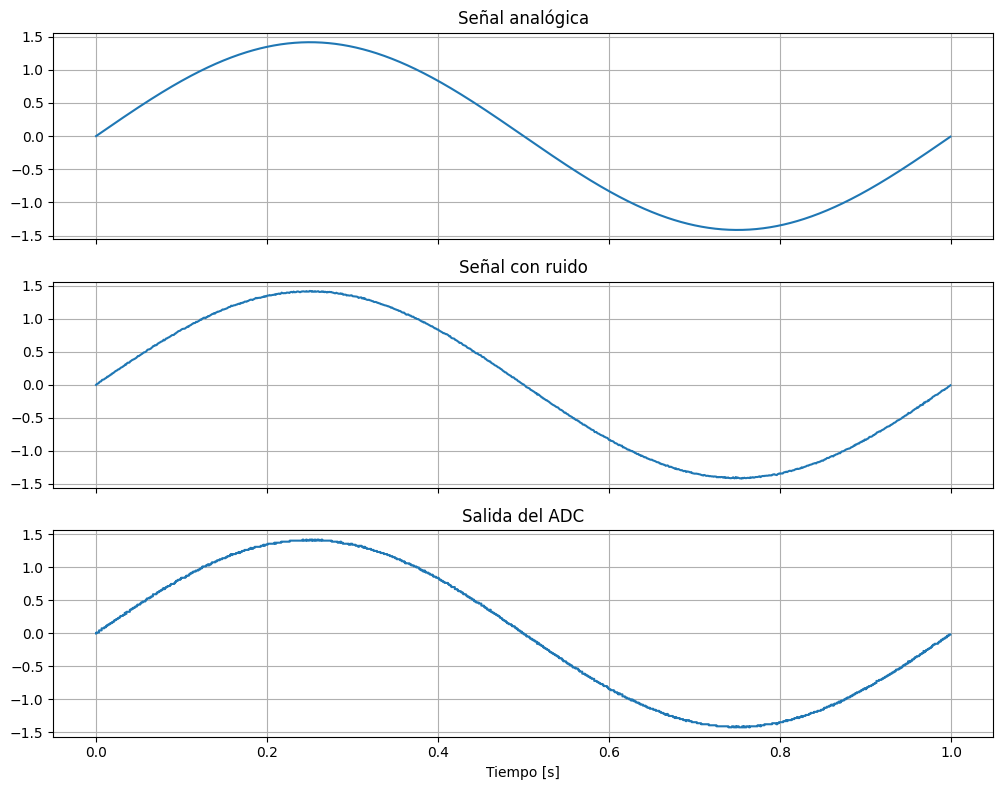

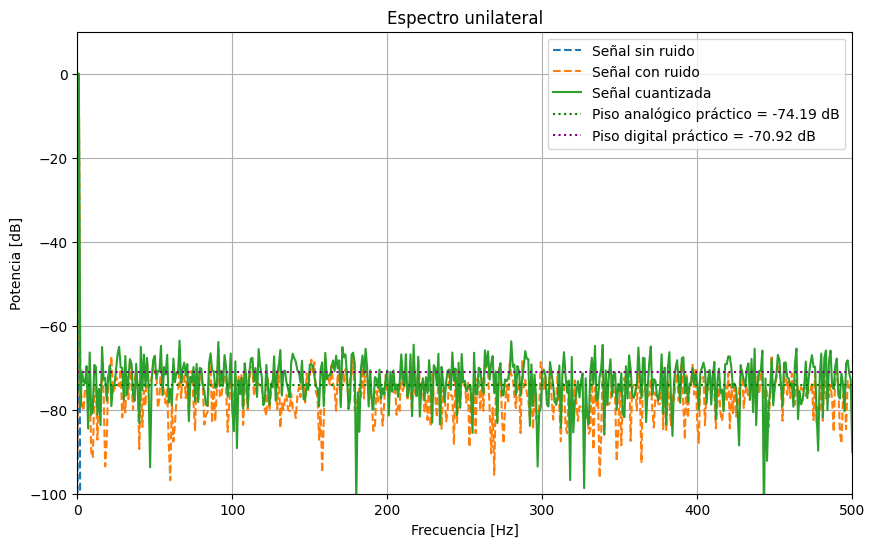

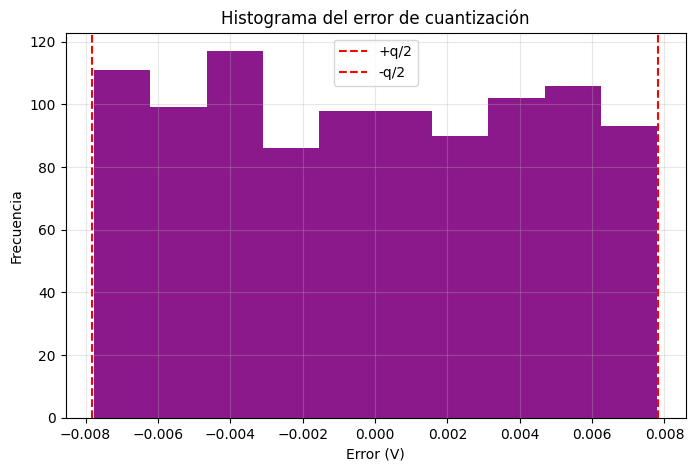

In [23]:

B=8
k=1
qq=2*Vfs/2**B
sigma =k* (qq**2)/12
# ruido gaussiano incorrelado
U_n = np.random.normal(mu, np.sqrt(sigma), N)

# ==================================================
# Señales
# ==================================================
tt, xx = mi_funcion_sen(vmax=vnor, dc=dcs, ff=ffs, ph=fas, nn=N, fs=fs)

xxun = xx + U_n
xxq = np.round(xxun / qq) * qq

# ==================================================
# FFT
# ==================================================
frec = np.arange(N) * df

XX = np.fft.fft(xx)
XXun = np.fft.fft(xxun)
XXq = np.fft.fft(xxq)

# ==================================================
# Potencia bilateral y normalizada
# ==================================================
Pxx = (np.abs(XX)**2) / (N**2)
Pxxun = (np.abs(XXun)**2) / (N**2)
Pxxq = (np.abs(XXq)**2) / (N**2)

# ==================================================
# Espectro unilateral
# ==================================================
frec_half = frec[:N//2 + 1]

Pxx_uni = Pxx[:N//2 + 1].copy()
Pxxun_uni = Pxxun[:N//2 + 1].copy()
Pxxq_uni = Pxxq[:N//2 + 1].copy()

Pxx_uni[1:-1] *= 2
Pxxun_uni[1:-1] *= 2
Pxxq_uni[1:-1] *= 2

# ==================================================
# Conversión a dB
# ==================================================
Pxx_uni_db = 10 * np.log10(Pxx_uni + 1e-12)
Pxxun_uni_db = 10 * np.log10(Pxxun_uni + 1e-12)
Pxxq_uni_db = 10 * np.log10(Pxxq_uni + 1e-12)

# ==================================================
# Pisos teóricos (solo para referencia)
# ==================================================
piso_analogico_teo = 10 * np.log10(2 * sigma / N)
sigma_q = qq**2 / 12
piso_digital_teo = 10 * np.log10(2 * sigma_q / N)

# ==================================================
# Pisos prácticos
# ==================================================
bin_tono = int(ffs / df)

ruido_analogico_lin = np.delete(Pxxun_uni, [0, bin_tono])
ruido_digital_lin = np.delete(Pxxq_uni, [0, bin_tono])

piso_analogico_practico = 10 * np.log10(np.mean(ruido_analogico_lin))
piso_digital_practico = 10 * np.log10(np.mean(ruido_digital_lin))

print(f"Piso analógico teórico  = {piso_analogico_teo:.2f} dB")
print(f"Piso analógico práctico = {piso_analogico_practico:.2f} dB")
print()
print(f"Piso digital teórico    = {piso_digital_teo:.2f} dB")
print(f"Piso digital práctico   = {piso_digital_practico:.2f} dB")

# ==================================================
# Señales temporales
# ==================================================
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(tt, xx)
ax[0].set_title('Señal analógica')
ax[0].grid(True)

ax[1].plot(tt, xxun)
ax[1].set_title('Señal con ruido')
ax[1].grid(True)

ax[2].step(tt, xxq, where='mid')
ax[2].set_title('Salida del ADC')
ax[2].set_xlabel('Tiempo [s]')
ax[2].grid(True)

plt.tight_layout()
plt.show()

# ==================================================
# Gráfico espectral
# ==================================================
plt.figure(figsize=(10, 6))

plt.plot(frec_half, Pxx_uni_db, '--', label='Señal sin ruido')
plt.plot(frec_half, Pxxun_uni_db, '--', label='Señal con ruido')
plt.plot(frec_half, Pxxq_uni_db, label='Señal cuantizada')

# SOLO pisos prácticos
plt.axhline(piso_analogico_practico, color='green', linestyle=':',
            label=f'Piso analógico práctico = {piso_analogico_practico:.2f} dB')

plt.axhline(piso_digital_practico, color='purple', linestyle=':',
            label=f'Piso digital práctico = {piso_digital_practico:.2f} dB')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.title('Espectro unilateral')
plt.ylim(-100, 10)
plt.xlim(0, fs/2)
plt.grid(True)
plt.legend()
plt.show()

# ==================================================
# Error de cuantización
# ==================================================
xxe = xxq - xxun

plt.figure(figsize=(8, 5))
plt.hist(xxe, bins=10, density=False, alpha=0.9, color='purple')
plt.axvline(qq/2, color='red', linestyle='--', label='+q/2')
plt.axvline(-qq/2, color='red', linestyle='--', label='-q/2')
plt.title('Histograma del error de cuantización')
plt.xlabel('Error (V)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

$k= 10 $, $B=16$  y graficos de las señales 

Piso analógico teórico  = -112.07 dB
Piso analógico práctico = -111.84 dB

Piso digital teórico    = -122.07 dB
Piso digital práctico   = -111.58 dB


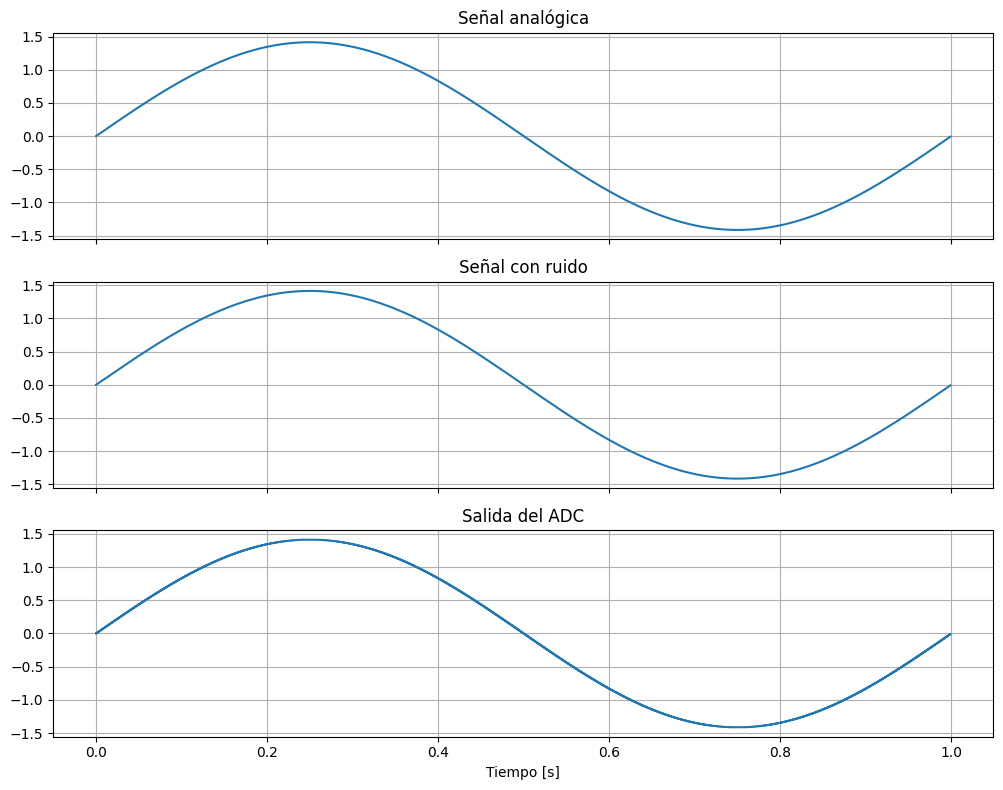

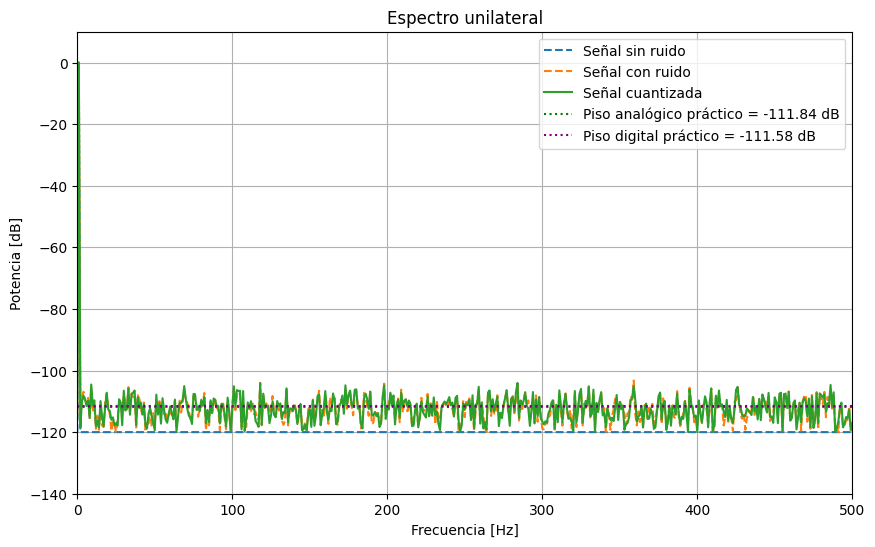

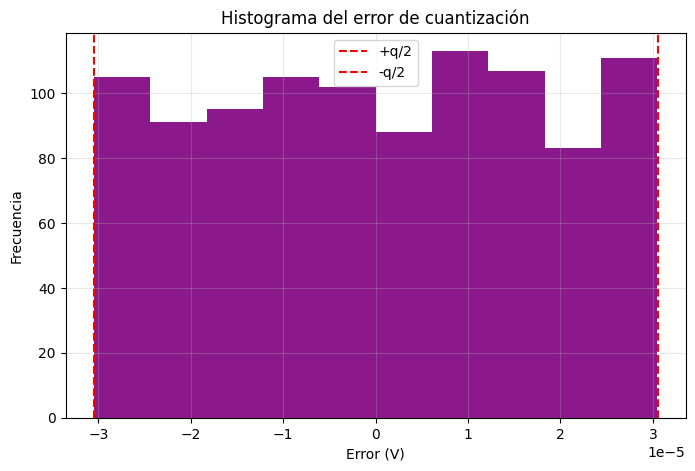

In [24]:

B=16
k=10
qq=2*Vfs/2**B
sigma =k* (qq**2)/12
# ruido gaussiano incorrelado
U_n = np.random.normal(mu, np.sqrt(sigma), N)

# ==================================================
# Señales
# ==================================================
tt, xx = mi_funcion_sen(vmax=vnor, dc=dcs, ff=ffs, ph=fas, nn=N, fs=fs)

xxun = xx + U_n
xxq = np.round(xxun / qq) * qq

# ==================================================
# FFT
# ==================================================
frec = np.arange(N) * df

XX = np.fft.fft(xx)
XXun = np.fft.fft(xxun)
XXq = np.fft.fft(xxq)

# ==================================================
# Potencia bilateral y normalizada
# ==================================================
Pxx = (np.abs(XX)**2) / (N**2)
Pxxun = (np.abs(XXun)**2) / (N**2)
Pxxq = (np.abs(XXq)**2) / (N**2)

# ==================================================
# Espectro unilateral
# ==================================================
frec_half = frec[:N//2 + 1]

Pxx_uni = Pxx[:N//2 + 1].copy()
Pxxun_uni = Pxxun[:N//2 + 1].copy()
Pxxq_uni = Pxxq[:N//2 + 1].copy()

Pxx_uni[1:-1] *= 2
Pxxun_uni[1:-1] *= 2
Pxxq_uni[1:-1] *= 2

# ==================================================
# Conversión a dB
# ==================================================
Pxx_uni_db = 10 * np.log10(Pxx_uni + 1e-12)
Pxxun_uni_db = 10 * np.log10(Pxxun_uni + 1e-12)
Pxxq_uni_db = 10 * np.log10(Pxxq_uni + 1e-12)

# ==================================================
# Pisos teóricos (solo para referencia)
# ==================================================
piso_analogico_teo = 10 * np.log10(2 * sigma / N)
sigma_q = qq**2 / 12
piso_digital_teo = 10 * np.log10(2 * sigma_q / N)

# ==================================================
# Pisos prácticos
# ==================================================
bin_tono = int(ffs / df)

ruido_analogico_lin = np.delete(Pxxun_uni, [0, bin_tono])
ruido_digital_lin = np.delete(Pxxq_uni, [0, bin_tono])

piso_analogico_practico = 10 * np.log10(np.mean(ruido_analogico_lin))
piso_digital_practico = 10 * np.log10(np.mean(ruido_digital_lin))

print(f"Piso analógico teórico  = {piso_analogico_teo:.2f} dB")
print(f"Piso analógico práctico = {piso_analogico_practico:.2f} dB")
print()
print(f"Piso digital teórico    = {piso_digital_teo:.2f} dB")
print(f"Piso digital práctico   = {piso_digital_practico:.2f} dB")

# ==================================================
# Señales temporales
# ==================================================
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(tt, xx)
ax[0].set_title('Señal analógica')
ax[0].grid(True)

ax[1].plot(tt, xxun)
ax[1].set_title('Señal con ruido')
ax[1].grid(True)

ax[2].step(tt, xxq, where='mid')
ax[2].set_title('Salida del ADC')
ax[2].set_xlabel('Tiempo [s]')
ax[2].grid(True)

plt.tight_layout()
plt.show()

# ==================================================
# Gráfico espectral
# ==================================================
plt.figure(figsize=(10, 6))

plt.plot(frec_half, Pxx_uni_db, '--', label='Señal sin ruido')
plt.plot(frec_half, Pxxun_uni_db, '--', label='Señal con ruido')
plt.plot(frec_half, Pxxq_uni_db, label='Señal cuantizada')

# SOLO pisos prácticos
plt.axhline(piso_analogico_practico, color='green', linestyle=':',
            label=f'Piso analógico práctico = {piso_analogico_practico:.2f} dB')

plt.axhline(piso_digital_practico, color='purple', linestyle=':',
            label=f'Piso digital práctico = {piso_digital_practico:.2f} dB')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.title('Espectro unilateral')
plt.ylim(-140, 10)
plt.xlim(0, fs/2)
plt.grid(True)
plt.legend()
plt.show()

# ==================================================
# Error de cuantización
# ==================================================
xxe = xxq - xxun

plt.figure(figsize=(8, 5))
plt.hist(xxe, bins=10, density=False, alpha=0.9, color='purple')
plt.axvline(qq/2, color='red', linestyle='--', label='+q/2')
plt.axvline(-qq/2, color='red', linestyle='--', label='-q/2')
plt.title('Histograma del error de cuantización')
plt.xlabel('Error (V)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

El comportamiento del sistema depende fundamentalmente de dos parámetros: el número de bits del ADC ($B$) y el nivel de ruido analógico, controlado mediante el factor $k_n$.

El número de bits $B$ determina la resolución del conversor, ya que fija el paso de cuantización:

$$
q = \frac{2V_F}{2^B}
$$

A medida que aumenta $B$, el valor de $q$ disminuye, lo que implica una reducción directa del error de cuantización. En los gráficos se observa que, al incrementar la cantidad de bits, el nivel de ruido de fondo desciende, permitiendo que el pico correspondiente a la señal se destaque con mayor claridad. En consecuencia, mejora la relación señal-ruido (SNR), logrando una representación más precisa de la señal original.

Por otro lado, el parámetro $k_n$ permite ajustar la potencia del ruido analógico agregado a la señal. Este factor escala la varianza del ruido según:

$$
\sigma^2 = k_n \cdot \frac{q^2}{12}
$$

Al aumentar $k_n$, el ruido analógico adquiere mayor relevancia, elevando el piso de ruido en todo el espectro. En este régimen, el comportamiento del sistema queda dominado por el entorno analógico, independientemente de la resolución del ADC. En cambio, cuando $k_n$ es pequeño, el ruido analógico resulta despreciable y el desempeño del sistema queda limitado principalmente por el proceso de cuantización.

Los resultados muestran claramente que ambos parámetros influyen sobre el piso de ruido, aunque mediante mecanismos distintos: mientras que $B$ controla la resolución del sistema digital, $k_n$ define el nivel de perturbación presente en la señal de entrada. La interacción entre ambos determina el régimen de operación, estableciendo si la limitación proviene del ADC o del ruido analógico.

En el histograma del error de cuantización se observa que al aumentar el número de bits $B$, el paso de cuantización $q$ disminuye, lo que reduce el rango del error. En consecuencia, el histograma se contrae alrededor del cero, permaneciendo dentro del intervalo $[-q/2, \, q/2]$, pero con una menor dispersión. Esto refleja una disminución del error introducido por el ADC y, por lo tanto, una mejora en la fidelidad de la señal digitalizada.

Por su parte, el parámetro $k_n$ influye en el carácter estadístico del error. Cuando $k_n$ es elevado, el ruido analógico introduce suficiente aleatoriedad en la señal de entrada, haciendo que el error de cuantización tienda a distribuirse de manera aproximadamente uniforme. 

En cambio, cuando $k_n$ es pequeño, la señal de entrada presenta un comportamiento más determinístico. Como consecuencia, el error de cuantización puede exhibir cierta estructura o dependencia con la señal, lo que se traduce en un histograma menos uniforme.


# Conclusión general

A partir de los resultados obtenidos, se evidencia que el desempeño de un sistema de adquisición digital está determinado por la interacción entre el ruido analógico presente en la señal de entrada y el ruido introducido por el proceso de cuantización del ADC.

El análisis en el dominio frecuencial, junto con el estudio del error de cuantización, permite verificar que ambos tipos de ruido se manifiestan como contribuciones aproximadamente blancas en el espectro, elevando el piso de ruido y afectando la relación señal-ruido. En donde, el número de bits del ADC define la resolución del sistema y, por lo tanto, el nivel de ruido de cuantización, mientras que el parámetro $k_n$ modela las condiciones del entorno analógico.

Se observa que, cuando el ruido de cuantización domina, la calidad de la señal digitalizada se ve limitada por el propio ADC, lo que implica una pérdida de información debido a la baja resolución. Por el contrario, cuando el ruido analógico es predominante, el conversor no introduce degradaciones significativas adicionales, sino que se limita a representar digitalmente una señal ya afectada por ruido externo.

Esto conduce a un criterio fundamental: el ADC debe seleccionarse de manera tal que su ruido de cuantización sea menor o igual que el ruido analógico del sistema. De este modo, se evita que el proceso de digitalización se convierta en el factor limitante, garantizando que el desempeño global esté determinado por las condiciones físicas de la señal y no por las limitaciones del conversor.